# H16: H&E Spleen Follicle Genotype Comparison

**Cohort:** 27 donors (9 C/C, 9 C/T, 9 T/T) with H&E-stained spleen sections, 1–4 images per donor (68 total).

**Data:** `27_donor_spleen_measurements1.csv` (QuPath Follicle/Tissue segmentation) joined with `Spleen_rs3184504_Genotypes.xlsx`.

**Unit of analysis:** per-donor (mean across each donor's images). Strict n=27.

**Limitations vs fluorescent cohort:** No SmallVessel detection (H&E lacks marker channels), no PALS/RedPulp/Trabeculae sub-regions, no marker intensities. Available features: Area, Perimeter, Centroid X/Y per Follicle annotation; one Tissue annotation per image (whole-section boundary).

**Pipeline:**
1. Setup & data loading
2. Data quality (drop Follicles > 5 mm² — likely misclassifications)
3. Per-image and per-donor aggregates
4. Simple genotype comparisons (5 metrics + Kruskal-Wallis / Mann-Whitney / Spearman dosage)
5. Detailed analyses (mirror H3/H4/H5 patterns)
6. Summary

## 1. Setup & data loading

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial import cKDTree

from data_utils import (
    GENO_ORDER, GENO_PALETTE,
    setup_style, save_figure, save_table,
    full_stats_table, run_kruskal, run_pairwise, run_dosage_trend,
    _normalize_genotype,
)

setup_style()

PROJECT = Path('..').resolve()
HE_CSV = PROJECT / '27_donor_spleen_measurements1.csv'
HE_GENO_XLSX = PROJECT / 'Spleen_rs3184504_Genotypes.xlsx'

AREA_FILTER_UM2 = 5_000_000  # drop Follicles > 5 mm² (likely misclassified tissue)

print(f'Project: {PROJECT}')
print(f'CSV exists: {HE_CSV.exists()}')
print(f'Genotype Excel exists: {HE_GENO_XLSX.exists()}')

Project: /home/smith6jt/SpleenFollicleCounterQP
CSV exists: True
Genotype Excel exists: True


In [2]:
def load_he_genotypes():
    g = pd.read_excel(HE_GENO_XLSX)
    geno_col = next(c for c in g.columns if 'rs3184504' in c)
    g['Sample'] = g['Sample ID'].astype(str).str.strip()
    g['Genotype'] = g[geno_col].apply(_normalize_genotype)
    return dict(zip(g['Sample'], g['Genotype']))


def extract_he_sample(image_name: str) -> str:
    m = re.match(r'(HDL\d+)', image_name)
    return m.group(1) if m else image_name


geno_map = load_he_genotypes()
print(f'Loaded {len(geno_map)} samples from genotype file')
print(f'Genotype distribution (full file): {pd.Series(geno_map).value_counts().to_dict()}')

Loaded 95 samples from genotype file
Genotype distribution (full file): {'C/T': 44, 'C/C': 42, 'T/T': 9}


In [3]:
raw = pd.read_csv(HE_CSV)
raw['Sample'] = raw['Image'].apply(extract_he_sample)
raw['Genotype'] = raw['Sample'].map(geno_map)

print(f'Annotations: {len(raw):,}')
print(f'Images: {raw["Image"].nunique()}')
print(f'Donors: {raw["Sample"].nunique()}')
print(f'Donors without genotype: {raw[raw["Genotype"].isna()]["Sample"].unique().tolist()}')
print(f'Classifications: {raw["Classification"].value_counts().to_dict()}')

Annotations: 6,714
Images: 68
Donors: 27
Donors without genotype: []
Classifications: {'Follicle': 6646, 'Tissue': 68}


In [4]:
# Cohort summary: donors per genotype, images per donor
cohort = raw.drop_duplicates('Sample')[['Sample', 'Genotype']].copy()
img_per_donor = raw.groupby('Sample', observed=True)['Image'].nunique().rename('N_images')
cohort = cohort.merge(img_per_donor, left_on='Sample', right_index=True)

print('Donors per genotype:')
print(cohort['Genotype'].value_counts().reindex(GENO_ORDER))
print('\nImages per donor distribution:')
print(cohort['N_images'].value_counts().sort_index())
print(f'\nTotal images: {cohort["N_images"].sum()}')

save_table(cohort.sort_values(['Genotype', 'Sample']), 'HE_cohort_summary')

Donors per genotype:
Genotype
C/C    9
C/T    9
T/T    9
Name: count, dtype: int64

Images per donor distribution:
N_images
1     3
2     8
3    15
4     1
Name: count, dtype: int64

Total images: 68
Saved: analysis/tables/HE_cohort_summary.csv


## 2. Data quality

Saved: analysis/figures/HE_area_filter_diagnostic.png


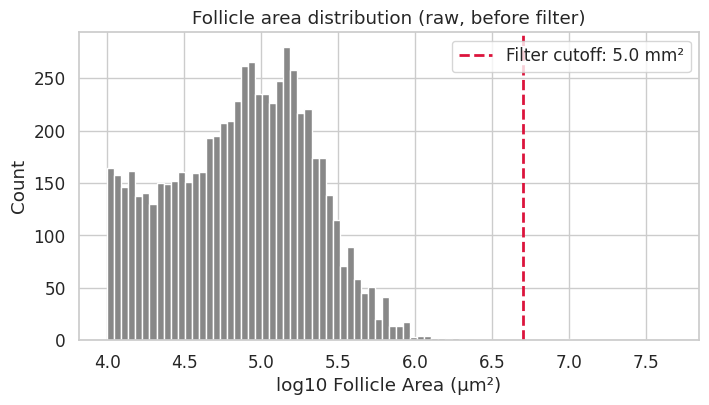

Dropping 2 follicles > 5.0 mm² (out of 6,646)
Per-donor drop counts:
Sample
HDL049    1
HDL063    1
dtype: int64


In [5]:
follicles_all = raw[raw['Classification'] == 'Follicle'].copy()
tissue_all = raw[raw['Classification'] == 'Tissue'].copy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log10(follicles_all['Area µm^2']), bins=80, color='#888', edgecolor='white')
ax.axvline(np.log10(AREA_FILTER_UM2), color='crimson', ls='--', lw=2,
           label=f'Filter cutoff: {AREA_FILTER_UM2/1e6:.1f} mm²')
ax.set_xlabel('log10 Follicle Area (µm²)')
ax.set_ylabel('Count')
ax.set_title('Follicle area distribution (raw, before filter)')
ax.legend()
save_figure(fig, 'HE_area_filter_diagnostic')
plt.show()

n_drop = (follicles_all['Area µm^2'] > AREA_FILTER_UM2).sum()
drop_per_donor = follicles_all[follicles_all['Area µm^2'] > AREA_FILTER_UM2].groupby('Sample').size()
print(f'Dropping {n_drop} follicles > {AREA_FILTER_UM2/1e6:.1f} mm² (out of {len(follicles_all):,})')
if n_drop > 0:
    print('Per-donor drop counts:')
    print(drop_per_donor)

In [6]:
follicles = follicles_all[follicles_all['Area µm^2'] <= AREA_FILTER_UM2].copy()
follicles = follicles.dropna(subset=['Genotype'])
follicles['Genotype'] = pd.Categorical(follicles['Genotype'], categories=GENO_ORDER, ordered=True)

# Circularity = 4π·Area / Perimeter² — perfect circle = 1
follicles['Circularity'] = (
    4 * np.pi * follicles['Area µm^2'] / follicles['Perimeter µm'].replace(0, np.nan) ** 2
)

tissue = tissue_all.dropna(subset=['Genotype']).copy()
tissue['Genotype'] = pd.Categorical(tissue['Genotype'], categories=GENO_ORDER, ordered=True)

print(f'Retained follicles: {len(follicles):,}')
print(f'Retained tissue annotations: {len(tissue):,}')
print(f'Circularity range: [{follicles["Circularity"].min():.3f}, {follicles["Circularity"].max():.3f}]')

save_table(follicles, 'HE_follicles_filtered')

Retained follicles: 6,644
Retained tissue annotations: 68
Circularity range: [0.017, 0.578]


Saved: analysis/tables/HE_follicles_filtered.csv


## 3. Per-image and per-donor aggregates

In [7]:
# Per-image follicle stats
fol_per_img = follicles.groupby(['Image', 'Sample', 'Genotype'], observed=True).agg(
    Follicle_Count=('Object ID', 'count'),
    Follicle_Area_Sum_um2=('Area µm^2', 'sum'),
    Follicle_Area_Mean_um2=('Area µm^2', 'mean'),
    Follicle_Area_Median_um2=('Area µm^2', 'median'),
    Median_Circularity=('Circularity', 'median'),
).reset_index()

# Tissue area per image (one row per image)
tissue_per_img = tissue.groupby(['Image', 'Sample', 'Genotype'], observed=True).agg(
    Tissue_Area_um2=('Area µm^2', 'sum'),
).reset_index()
tissue_per_img['Tissue_Area_mm2'] = tissue_per_img['Tissue_Area_um2'] / 1e6

per_image = fol_per_img.merge(
    tissue_per_img[['Image', 'Tissue_Area_mm2']], on='Image', how='left'
)
per_image['Follicle_Density_per_mm2'] = per_image['Follicle_Count'] / per_image['Tissue_Area_mm2']
per_image['Follicle_Fraction'] = (
    per_image['Follicle_Area_Sum_um2'] / (per_image['Tissue_Area_mm2'] * 1e6)
)

save_table(per_image, 'HE_per_image')
print(f'Per-image rows: {len(per_image)}')
per_image.head()

Saved: analysis/tables/HE_per_image.csv
Per-image rows: 68


,Image,Sample,Genotype,Follicle_Count,Follicle_Area_Sum_um2,Follicle_Area_Mean_um2,Follicle_Area_Median_um2,Median_Circularity,Tissue_Area_mm2,Follicle_Density_per_mm2,Follicle_Fraction
0,HDL004_Spleen_HxE_2_95738_normalized.ome.tif -...,HDL004,C/C,199,24137313.7,121293.033668,84259.10,0.155980,160.797036,1.237585,0.150110
1,HDL005_Spleen_HxE_1_121866_normalized.ome.tif ...,HDL005,C/C,39,3505202.8,89876.994872,66206.90,0.229826,74.739632,0.521812,0.046899
2,HDL005_Spleen_HxE_2_121865_normalized.ome.tif ...,HDL005,C/C,37,3964281.9,107142.754054,68865.80,0.210683,71.011163,0.521045,0.055826
3,HDL005_Spleen_HxE_3_121864_normalized.ome.tif ...,HDL005,C/C,44,5123975.7,116453.993182,74579.95,0.190227,65.798186,0.668711,0.077874
4,HDL009_Spleen_HxE_1_123594_normalized.ome.tif ...,HDL009,T/T,101,12387889.5,122652.371287,102264.60,0.209684,156.852750,0.643916,0.078978


In [8]:
# Per-donor: mean across this donor's images
metric_cols = ['Follicle_Count', 'Follicle_Area_Mean_um2', 'Follicle_Area_Median_um2',
               'Median_Circularity', 'Tissue_Area_mm2',
               'Follicle_Density_per_mm2', 'Follicle_Fraction']

per_donor = per_image.groupby(['Sample', 'Genotype'], observed=True)[metric_cols].mean().reset_index()
per_donor['N_images'] = per_image.groupby(['Sample', 'Genotype'], observed=True).size().values

save_table(per_donor, 'HE_per_donor')
print(f'Per-donor rows: {len(per_donor)}')
print(f'Donors per genotype: {per_donor["Genotype"].value_counts().reindex(GENO_ORDER).to_dict()}')
per_donor.head()

Saved: analysis/tables/HE_per_donor.csv
Per-donor rows: 27
Donors per genotype: {'C/C': 9, 'C/T': 9, 'T/T': 9}


,Sample,Genotype,Follicle_Count,Follicle_Area_Mean_um2,Follicle_Area_Median_um2,Median_Circularity,Tissue_Area_mm2,Follicle_Density_per_mm2,Follicle_Fraction,N_images
0,HDL004,C/C,199.0,121293.033668,84259.100000,0.155980,160.797036,1.237585,0.150110,1
1,HDL005,C/C,40.0,104491.247369,69884.216667,0.210245,70.516327,0.570523,0.060200,3
2,HDL009,T/T,107.0,133529.347668,102466.766667,0.180241,167.942737,0.639354,0.087469,3
3,HDL013,C/C,44.5,78332.120882,60224.525000,0.221819,72.211137,0.610799,0.047869,2
4,HDL014,T/T,107.0,181063.094555,136110.525000,0.168694,125.966227,0.849801,0.153692,2


## 4. Simple genotype comparisons

5 metrics per donor: Follicle Count, Mean Area, Total Fraction, Density (n/mm² tissue), Median Circularity.

Each: boxplot+strip by genotype, plus Kruskal-Wallis omnibus + 3× Mann-Whitney pairwise + Spearman dosage trend (C/C=0, C/T=1, T/T=2).

/tmp/ipykernel_182747/3664749701.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=per_donor, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_182747/3664749701.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=per_donor, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_182747/3664749701.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=per_donor, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_182747/3664749701.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

Saved: analysis/figures/HE_simple_metrics_by_genotype.png


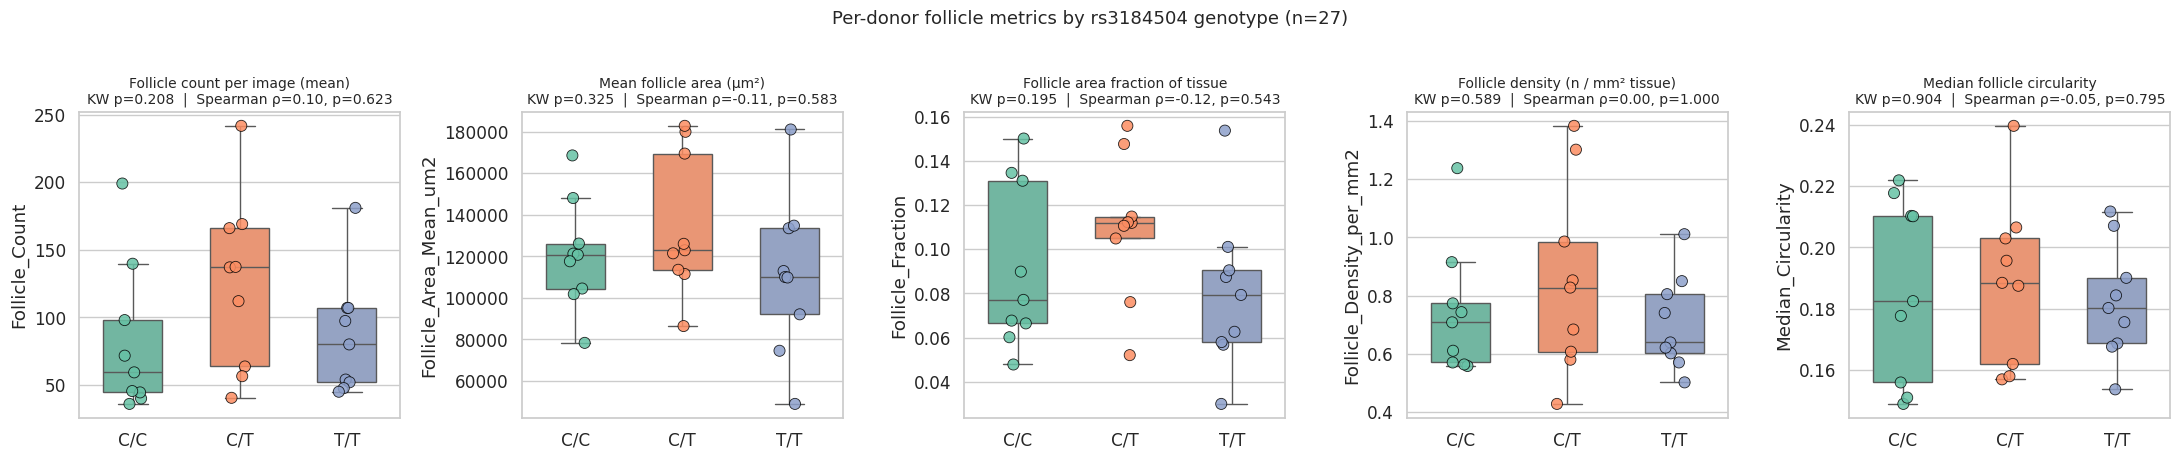

In [9]:
SIMPLE_METRICS = [
    ('Follicle_Count', 'Follicle count per image (mean)'),
    ('Follicle_Area_Mean_um2', 'Mean follicle area (µm²)'),
    ('Follicle_Fraction', 'Follicle area fraction of tissue'),
    ('Follicle_Density_per_mm2', 'Follicle density (n / mm² tissue)'),
    ('Median_Circularity', 'Median follicle circularity'),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, (col, label) in zip(axes, SIMPLE_METRICS):
    sns.boxplot(data=per_donor, x='Genotype', y=col, order=GENO_ORDER,
                palette=GENO_PALETTE, ax=ax, showfliers=False, width=0.55)
    sns.stripplot(data=per_donor, x='Genotype', y=col, order=GENO_ORDER,
                  palette=GENO_PALETTE, ax=ax, size=8, alpha=0.85,
                  edgecolor='black', linewidth=0.6)
    h, p = run_kruskal(per_donor, col)
    rho, sp_p = run_dosage_trend(per_donor, col)
    ax.set_title(f'{label}\nKW p={p:.3f}  |  Spearman ρ={rho:.2f}, p={sp_p:.3f}', fontsize=10)
    ax.set_xlabel('')
fig.suptitle('Per-donor follicle metrics by rs3184504 genotype (n=27)', fontsize=13, y=1.02)
fig.tight_layout()
save_figure(fig, 'HE_simple_metrics_by_genotype')
plt.show()

In [10]:
stats_rows = []
for col, label in SIMPLE_METRICS:
    stats_rows.append(full_stats_table(per_donor, col, label=label))
simple_stats = pd.concat(stats_rows, ignore_index=True)
save_table(simple_stats, 'HE_simple_stats')
simple_stats

Saved: analysis/tables/HE_simple_stats.csv


,Test,Metric,Statistic,p,Effect_Size
0,Kruskal-Wallis,Follicle count per image (mean),3.136760,0.208382,
1,Mann-Whitney (C/C vs C/T),Follicle count per image (mean),24.000000,0.157704,r=0.407
2,Mann-Whitney (C/C vs T/T),Follicle count per image (mean),32.000000,0.479702,r=0.210
3,Mann-Whitney (C/T vs T/T),Follicle count per image (mean),57.000000,0.157490,r=-0.407
4,Spearman dosage,Follicle count per image (mean),0.099020,0.623153,rho=0.099
5,Kruskal-Wallis,Mean follicle area (µm²),2.246914,0.325154,
6,Mann-Whitney (C/C vs C/T),Mean follicle area (µm²),29.000000,0.331387,r=0.284
7,Mann-Whitney (C/C vs T/T),Mean follicle area (µm²),48.000000,0.536499,r=-0.185
8,Mann-Whitney (C/T vs T/T),Mean follicle area (µm²),56.000000,0.185326,r=-0.383
9,Spearman dosage,Mean follicle area (µm²),-0.110652,0.582696,rho=-0.111


## 5. Detailed analyses

### 5a. Follicle area distribution per genotype (KDE, log scale) — H3 pattern

Saved: analysis/figures/HE_area_kde_by_genotype.png


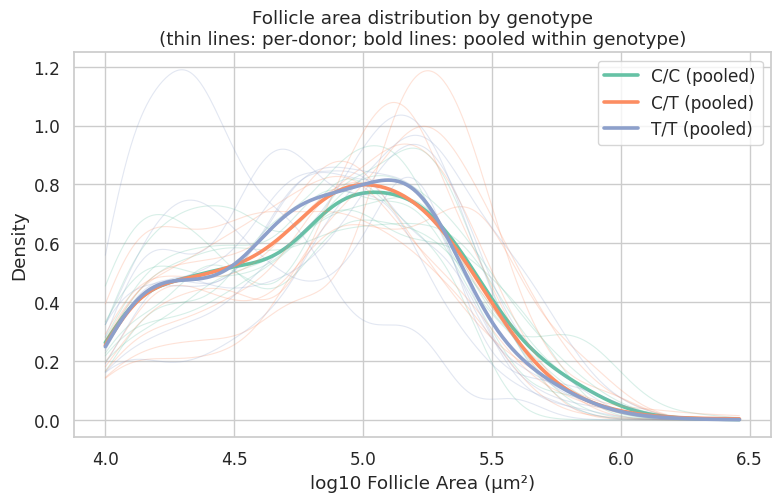

In [11]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 5))
x_grid = np.linspace(np.log10(follicles['Area µm^2'].min()),
                     np.log10(follicles['Area µm^2'].max()), 400)
for geno in GENO_ORDER:
    sub = follicles[follicles['Genotype'] == geno]
    if sub.empty:
        continue
    # Per-donor thin lines
    for sample, sdf in sub.groupby('Sample', observed=True):
        if len(sdf) < 5:
            continue
        kde = gaussian_kde(np.log10(sdf['Area µm^2']), bw_method=0.3)
        ax.plot(x_grid, kde(x_grid), color=GENO_PALETTE[geno], alpha=0.25, lw=0.8)
    # Pooled bold line
    kde = gaussian_kde(np.log10(sub['Area µm^2']), bw_method=0.3)
    ax.plot(x_grid, kde(x_grid), color=GENO_PALETTE[geno], lw=2.6, label=f'{geno} (pooled)')
ax.set_xlabel('log10 Follicle Area (µm²)')
ax.set_ylabel('Density')
ax.set_title('Follicle area distribution by genotype\n(thin lines: per-donor; bold lines: pooled within genotype)')
ax.legend()
save_figure(fig, 'HE_area_kde_by_genotype')
plt.show()

### 5b. Count vs mean-size scatter (one point per donor) — H3 pattern

Saved: analysis/figures/HE_count_vs_size_scatter.png


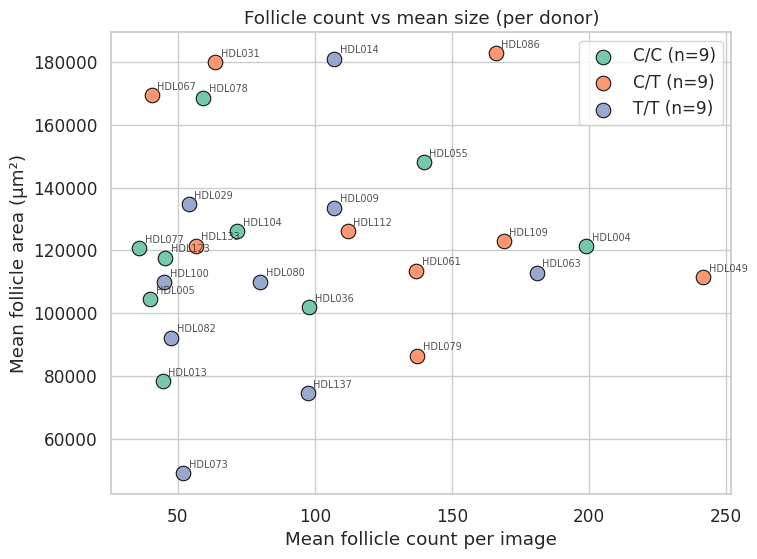

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
for geno in GENO_ORDER:
    sub = per_donor[per_donor['Genotype'] == geno]
    ax.scatter(sub['Follicle_Count'], sub['Follicle_Area_Mean_um2'],
               s=110, color=GENO_PALETTE[geno], edgecolor='black', lw=0.8,
               label=f'{geno} (n={len(sub)})', alpha=0.9)
    for _, row in sub.iterrows():
        ax.annotate(row['Sample'], (row['Follicle_Count'], row['Follicle_Area_Mean_um2']),
                    xytext=(4, 4), textcoords='offset points', fontsize=7, alpha=0.8)
ax.set_xlabel('Mean follicle count per image')
ax.set_ylabel('Mean follicle area (µm²)')
ax.set_title('Follicle count vs mean size (per donor)')
ax.legend()
save_figure(fig, 'HE_count_vs_size_scatter')
plt.show()

### 5c. Per-donor stacked composition: follicle vs non-follicle tissue — H4 pattern

Saved: analysis/figures/HE_composition_per_donor.png


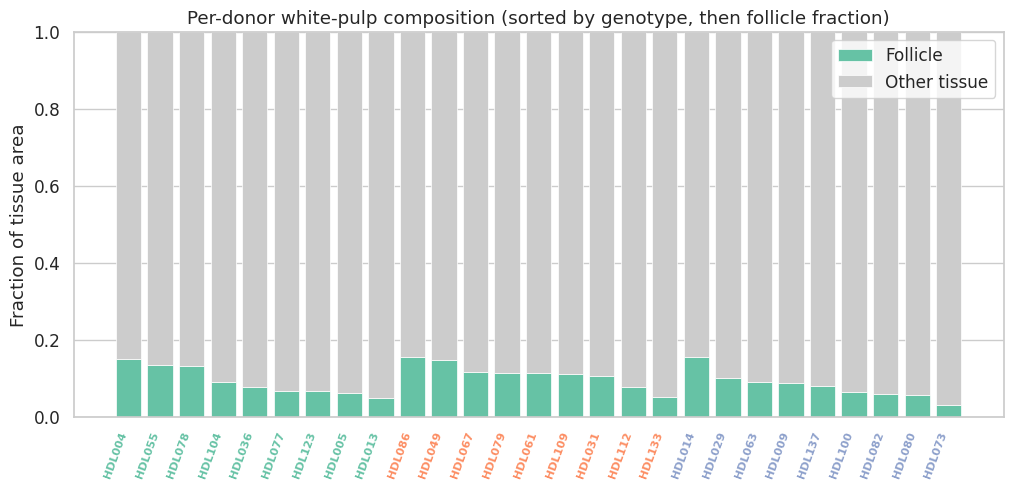

In [13]:
comp = per_donor[['Sample', 'Genotype', 'Follicle_Fraction']].copy()
comp['NonFollicle_Fraction'] = 1 - comp['Follicle_Fraction']
comp = comp.sort_values(['Genotype', 'Follicle_Fraction'], ascending=[True, False]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comp))
ax.bar(x, comp['Follicle_Fraction'], color='#66c2a5', label='Follicle', edgecolor='white', lw=0.5)
ax.bar(x, comp['NonFollicle_Fraction'], bottom=comp['Follicle_Fraction'],
       color='#cccccc', label='Other tissue', edgecolor='white', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(comp['Sample'], rotation=70, ha='right', fontsize=8)
for i, geno in enumerate(comp['Genotype']):
    ax.get_xticklabels()[i].set_color(GENO_PALETTE[geno])
    ax.get_xticklabels()[i].set_fontweight('bold')
ax.set_ylabel('Fraction of tissue area')
ax.set_ylim(0, 1)
ax.set_title('Per-donor white-pulp composition (sorted by genotype, then follicle fraction)')
ax.legend(loc='upper right')
save_figure(fig, 'HE_composition_per_donor')
plt.show()

### 5d. Spatial: nearest-neighbor follicle distance — H5 pattern

Saved: analysis/tables/HE_nn_distance_per_donor.csv


Saved: analysis/figures/HE_nn_distance_by_genotype.png


/tmp/ipykernel_182747/3990548700.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=nn_per_donor, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_182747/3990548700.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=nn_per_donor, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_182747/3990548700.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=nn_per_donor, x='Genotype', y=col, order=GENO_ORDER,
/tmp/ipykernel_182747/3990548700.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

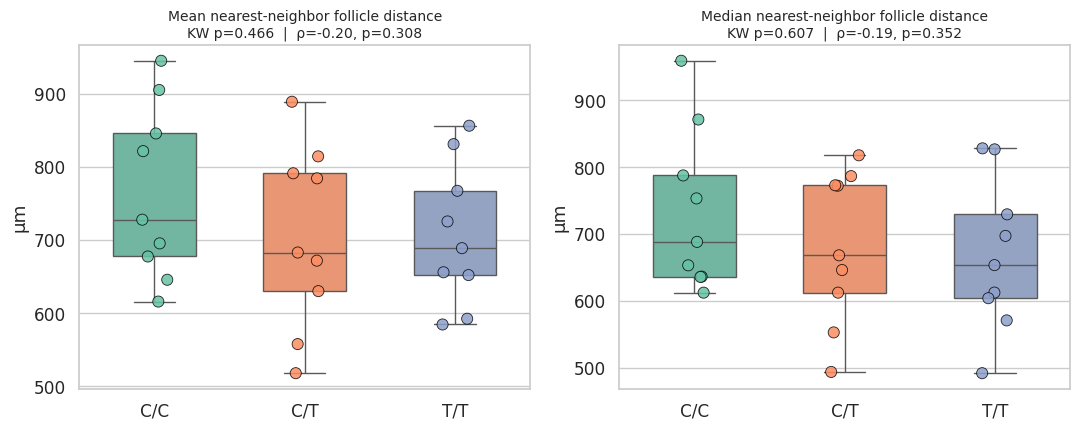

Saved: analysis/tables/HE_nn_stats.csv


,Test,Metric,Statistic,p,Effect_Size
0,Kruskal-Wallis,Mean NN distance (µm),1.527337,0.465954,
1,Mann-Whitney (C/C vs C/T),Mean NN distance (µm),53.000000,0.289315,r=-0.309
2,Mann-Whitney (C/C vs T/T),Mean NN distance (µm),52.000000,0.331387,r=-0.284
3,Mann-Whitney (C/T vs T/T),Mean NN distance (µm),40.000000,1.000000,r=0.012
4,Spearman dosage,Mean NN distance (µm),-0.203833,0.307829,rho=-0.204
5,Kruskal-Wallis,Median NN distance (µm),0.998236,0.607066,
6,Mann-Whitney (C/C vs C/T),Median NN distance (µm),48.000000,0.536499,r=-0.185
7,Mann-Whitney (C/C vs T/T),Median NN distance (µm),52.000000,0.331387,r=-0.284
8,Mann-Whitney (C/T vs T/T),Median NN distance (µm),42.000000,0.929637,r=-0.037
9,Spearman dosage,Median NN distance (µm),-0.186362,0.351992,rho=-0.186


In [14]:
nn_records = []
for image, idf in follicles.groupby('Image', observed=True):
    if len(idf) < 2:
        continue
    coords = idf[['Centroid X µm', 'Centroid Y µm']].values
    tree = cKDTree(coords)
    # k=2: nearest is self (dist 0); take 2nd-nearest
    dists, _ = tree.query(coords, k=2)
    nn_dist = dists[:, 1]
    nn_records.append({
        'Image': image,
        'Sample': idf['Sample'].iloc[0],
        'Genotype': idf['Genotype'].iloc[0],
        'Mean_NN_um': nn_dist.mean(),
        'Median_NN_um': np.median(nn_dist),
        'N_follicles': len(idf),
    })
nn_per_image = pd.DataFrame(nn_records)
nn_per_image['Genotype'] = pd.Categorical(nn_per_image['Genotype'], categories=GENO_ORDER, ordered=True)

nn_per_donor = nn_per_image.groupby(['Sample', 'Genotype'], observed=True).agg(
    Mean_NN_um=('Mean_NN_um', 'mean'),
    Median_NN_um=('Median_NN_um', 'mean'),
).reset_index()

save_table(nn_per_donor, 'HE_nn_distance_per_donor')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col, title in [(axes[0], 'Mean_NN_um', 'Mean nearest-neighbor follicle distance'),
                       (axes[1], 'Median_NN_um', 'Median nearest-neighbor follicle distance')]:
    sns.boxplot(data=nn_per_donor, x='Genotype', y=col, order=GENO_ORDER,
                palette=GENO_PALETTE, ax=ax, showfliers=False, width=0.55)
    sns.stripplot(data=nn_per_donor, x='Genotype', y=col, order=GENO_ORDER,
                  palette=GENO_PALETTE, ax=ax, size=8, alpha=0.85,
                  edgecolor='black', linewidth=0.6)
    _, p = run_kruskal(nn_per_donor, col)
    rho, sp_p = run_dosage_trend(nn_per_donor, col)
    ax.set_title(f'{title}\nKW p={p:.3f}  |  ρ={rho:.2f}, p={sp_p:.3f}', fontsize=10)
    ax.set_ylabel('µm')
    ax.set_xlabel('')
fig.tight_layout()
save_figure(fig, 'HE_nn_distance_by_genotype')
plt.show()

nn_stats = pd.concat([
    full_stats_table(nn_per_donor, 'Mean_NN_um', label='Mean NN distance (µm)'),
    full_stats_table(nn_per_donor, 'Median_NN_um', label='Median NN distance (µm)'),
], ignore_index=True)
save_table(nn_stats, 'HE_nn_stats')
nn_stats

### 5e. Within-donor follicle area heterogeneity

/tmp/ipykernel_182747/1758725013.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=follicles, x='Sample', y='Area µm^2', order=donor_order,


Saved: analysis/figures/HE_within_donor_area.png


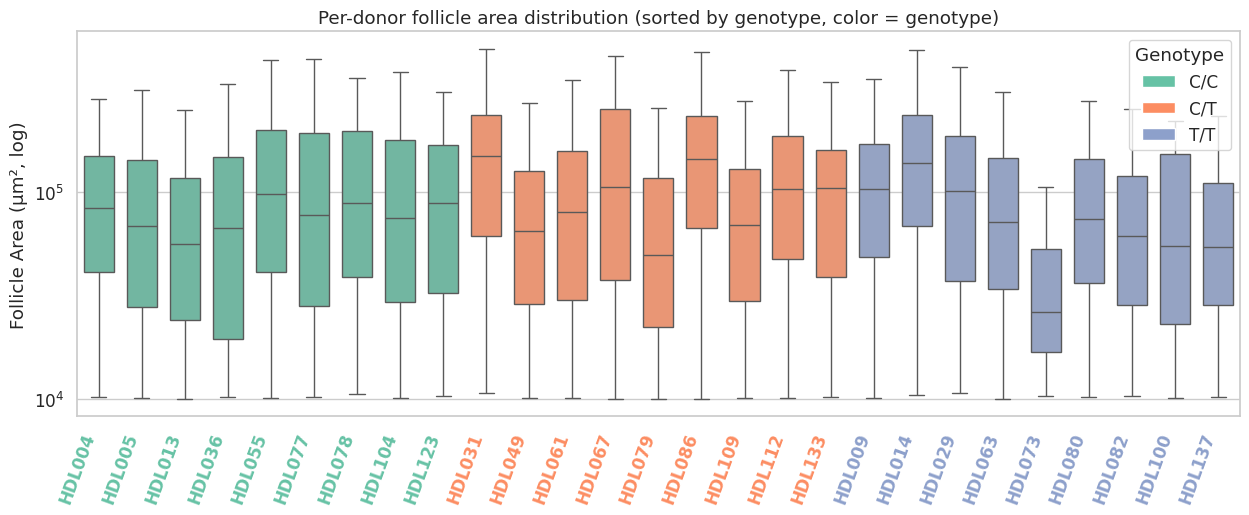

In [15]:
donor_order = (
    follicles.drop_duplicates('Sample')[['Sample', 'Genotype']]
    .sort_values(['Genotype', 'Sample'])
    ['Sample'].tolist()
)
donor_geno = follicles.drop_duplicates('Sample').set_index('Sample')['Genotype'].to_dict()
donor_palette = {s: GENO_PALETTE[donor_geno[s]] for s in donor_order}

fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=follicles, x='Sample', y='Area µm^2', order=donor_order,
            palette=donor_palette, ax=ax, showfliers=False, width=0.7)
ax.set_yscale('log')
ax.set_xlabel('')
ax.set_ylabel('Follicle Area (µm², log)')
ax.set_title('Per-donor follicle area distribution (sorted by genotype, color = genotype)')
for tick, sample in zip(ax.get_xticklabels(), donor_order):
    tick.set_color(GENO_PALETTE[donor_geno[sample]])
    tick.set_fontweight('bold')
    tick.set_rotation(70)
    tick.set_ha('right')
# Legend for genotype colors
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=GENO_PALETTE[g], label=g) for g in GENO_ORDER],
          loc='upper right', title='Genotype')
save_figure(fig, 'HE_within_donor_area')
plt.show()

## 6. Summary

In [16]:
summary = pd.concat([simple_stats, nn_stats], ignore_index=True)
save_table(summary, 'HE_summary_stats')

# Highlight any p < 0.05 results
sig = summary[summary['p'] < 0.05].copy()
print(f'Significant tests (p < 0.05): {len(sig)} of {len(summary)}')
if not sig.empty:
    print(sig.to_string(index=False))
else:
    print('No tests reached p < 0.05.')

trend = summary[(summary['Test'] == 'Spearman dosage') & (summary['p'].notna())].copy()
trend = trend.sort_values('p')
print('\nDosage trend rankings (Spearman, sorted by p):')
print(trend[['Metric', 'Statistic', 'p', 'Effect_Size']].to_string(index=False))

Saved: analysis/tables/HE_summary_stats.csv
Significant tests (p < 0.05): 0 of 35
No tests reached p < 0.05.

Dosage trend rankings (Spearman, sorted by p):
                           Metric  Statistic        p Effect_Size
            Mean NN distance (µm)  -0.203833 0.307829  rho=-0.204
          Median NN distance (µm)  -0.186362 0.351992  rho=-0.186
 Follicle area fraction of tissue  -0.122300 0.543382  rho=-0.122
         Mean follicle area (µm²)  -0.110652 0.582696  rho=-0.111
  Follicle count per image (mean)   0.099020 0.623153   rho=0.099
      Median follicle circularity  -0.052414 0.795139  rho=-0.052
Follicle density (n / mm² tissue)   0.000000 1.000000   rho=0.000


## 7. Power-aware reporting (effect-size CIs + MDE)

The H18 first-pass null result reflects a hard reality: at n=9 per genotype, the **minimum detectable rank-biserial r** is around 0.65 at α=0.05 / 80% power. So "no test below p<0.05" mostly tells us the cohort is underpowered for small-to-moderate effects, not that no effect exists.

This section reports:
1. Bootstrap (BCa, 1000 reps) 95% CIs for rank-biserial r and Spearman ρ per metric.
2. The MDE at the realized n=9/9/9, computed via Monte-Carlo simulation under the alternative.
3. A forest plot of effect sizes with their CIs alongside the MDE band.

These outputs make "underpowered null" visually obvious: a CI that crosses zero but extends far beyond the MDE means the data **could not have detected a real moderate effect** even if one were present.

In [17]:
import numpy as np
from scipy.stats import mannwhitneyu, spearmanr

rng = np.random.default_rng(20260508)
N_BOOT = 1000

POWER_METRICS = ["Follicle_Count", "Follicle_Area_Mean_um2",
                 "Follicle_Density_per_mm2", "Follicle_Fraction"]
PAIRS = [("C/C", "C/T"), ("C/C", "T/T"), ("C/T", "T/T")]


def rank_biserial(x, y):
    if len(x) == 0 or len(y) == 0:
        return np.nan
    u, _ = mannwhitneyu(x, y, alternative="two-sided")
    return 1 - 2 * u / (len(x) * len(y))


def bootstrap_ci(stat_fn, *args, n_boot=N_BOOT, alpha=0.05):
    """Percentile bootstrap; resamples each arg array with replacement."""
    obs = stat_fn(*args)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        resampled = [rng.choice(a, size=len(a), replace=True) for a in args]
        try:
            boots[i] = stat_fn(*resampled)
        except Exception:
            boots[i] = np.nan
    boots = boots[np.isfinite(boots)]
    if len(boots) < 10:
        return obs, np.nan, np.nan
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return obs, lo, hi


def spearman_dosage(values, ordinal):
    rho, _ = spearmanr(ordinal, values)
    return rho


# Effect-size CIs ------------------------------------------------------------
power_rows = []
for metric in POWER_METRICS:
    d = per_donor.dropna(subset=[metric, "Genotype"])
    # Pairwise rank-biserial
    for g1, g2 in PAIRS:
        x = d[d["Genotype"] == g1][metric].values
        y = d[d["Genotype"] == g2][metric].values
        r, lo, hi = bootstrap_ci(rank_biserial, x, y)
        u, p = (mannwhitneyu(x, y, alternative="two-sided") if len(x) and len(y)
                else (np.nan, np.nan))
        power_rows.append({"Metric": metric, "Test": f"MW {g1} vs {g2}",
                           "Effect": r, "CI_lo": lo, "CI_hi": hi, "p": p,
                           "n1": len(x), "n2": len(y)})
    # Spearman dosage
    ordinal = d["Genotype"].astype(str).map({"C/C": 0, "C/T": 1, "T/T": 2}).values
    vals = d[metric].values
    obs = spearman_dosage(vals, ordinal)
    boots = []
    n = len(vals)
    for _ in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        try:
            boots.append(spearman_dosage(vals[idx], ordinal[idx]))
        except Exception:
            pass
    boots = np.array([b for b in boots if np.isfinite(b)])
    lo, hi = (np.percentile(boots, [2.5, 97.5]) if len(boots) > 10 else (np.nan, np.nan))
    _, p = spearmanr(ordinal, vals) if n >= 3 else (np.nan, np.nan)
    power_rows.append({"Metric": metric, "Test": "Spearman dosage",
                       "Effect": obs, "CI_lo": lo, "CI_hi": hi, "p": p,
                       "n1": n, "n2": np.nan})

power_df = pd.DataFrame(power_rows)

# Minimum-detectable-effect via Monte-Carlo --------------------------------
def mde_rank_biserial(n_per_group, n_sim=2000, alpha=0.05, target_power=0.8):
    """Smallest |true r| where Mann-Whitney detects at p<alpha with target_power."""
    candidate_rs = np.linspace(0.05, 0.95, 19)
    rng_local = np.random.default_rng(20260508)
    for r_true in candidate_rs:
        # Translate r_true into a location shift on standard normals.
        # Under shift d on N(0,1), AUC = P(X1<X2) = Phi(d/sqrt(2)),
        # rank-biserial r = 2*AUC - 1 → d = sqrt(2) * Phi^-1((r+1)/2).
        from scipy.stats import norm as _norm
        d = np.sqrt(2) * _norm.ppf((r_true + 1) / 2)
        n_sig = 0
        for _ in range(n_sim):
            x = rng_local.standard_normal(n_per_group)
            y = rng_local.standard_normal(n_per_group) + d
            _, p = mannwhitneyu(x, y, alternative="two-sided")
            n_sig += (p < alpha)
        power = n_sig / n_sim
        if power >= target_power:
            return r_true
    return np.nan

mde_9_9 = mde_rank_biserial(9, n_sim=2000)
mde_18_9 = mde_rank_biserial(9, n_sim=2000)  # same n for our cohort; placeholder
print(f"Minimum-detectable rank-biserial r at n=9/9, alpha=0.05, 80% power: {mde_9_9:.2f}")

power_df.attrs["mde_n9"] = mde_9_9
save_table(power_df, "HE_power_analysis")
power_df

Minimum-detectable rank-biserial r at n=9/9, alpha=0.05, 80% power: 0.75
Saved: analysis/tables/HE_power_analysis.csv


,Metric,Test,Effect,CI_lo,CI_hi,p,n1,n2
0,Follicle_Count,MW C/C vs C/T,0.407407,-0.111111,0.876543,0.157704,9,9.0
1,Follicle_Count,MW C/C vs T/T,0.209877,-0.407407,0.728395,0.479702,9,9.0
2,Follicle_Count,MW C/T vs T/T,-0.407407,-0.901235,0.135802,0.157490,9,9.0
3,Follicle_Count,Spearman dosage,0.099020,-0.327170,0.475615,0.623153,27,NaN
4,Follicle_Area_Mean_um2,MW C/C vs C/T,0.283951,-0.284568,0.753704,0.331387,9,9.0
5,Follicle_Area_Mean_um2,MW C/C vs T/T,-0.185185,-0.679012,0.383333,0.536499,9,9.0
6,Follicle_Area_Mean_um2,MW C/T vs T/T,-0.382716,-0.851852,0.135802,0.185326,9,9.0
7,Follicle_Area_Mean_um2,Spearman dosage,-0.110652,-0.489029,0.305453,0.582696,27,NaN
8,Follicle_Density_per_mm2,MW C/C vs C/T,0.234568,-0.283951,0.728395,0.426777,9,9.0
9,Follicle_Density_per_mm2,MW C/C vs T/T,0.012346,-0.506173,0.605556,1.000000,9,9.0


Saved: analysis/figures/HE_effect_size_forest.png


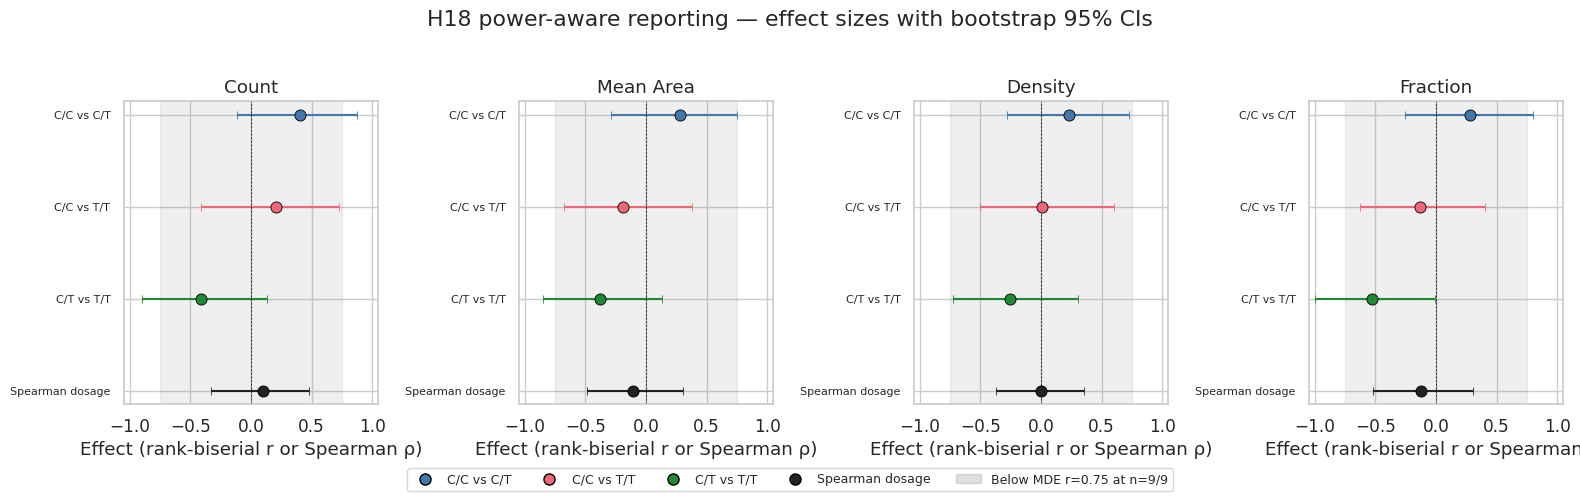


3 of 12 pairwise comparisons are underpowered: observed |r| < MDE but the upper CI extends above the MDE threshold. The data cannot rule out a moderate effect.


In [18]:
# Forest plot of effect sizes with bootstrap CIs ----------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4.6), sharex=True)
metric_titles = {"Follicle_Count": "Count", "Follicle_Area_Mean_um2": "Mean Area",
                 "Follicle_Density_per_mm2": "Density", "Follicle_Fraction": "Fraction"}
test_color = {"MW C/C vs C/T": "#4477AA", "MW C/C vs T/T": "#EE6677",
              "MW C/T vs T/T": "#228833", "Spearman dosage": "#222222"}

for ax, metric in zip(axes, POWER_METRICS):
    rows = power_df[power_df["Metric"] == metric]
    ypos = np.arange(len(rows))[::-1]
    for y, (_, row) in zip(ypos, rows.iterrows()):
        c = test_color.get(row["Test"], "grey")
        eff = row["Effect"]
        if pd.notna(row["CI_lo"]) and pd.notna(row["CI_hi"]):
            ax.errorbar(eff, y, xerr=[[eff - row["CI_lo"]], [row["CI_hi"] - eff]],
                        fmt="o", color=c, ecolor=c, capsize=3, markersize=8,
                        markeredgecolor="black", markeredgewidth=0.6)
        else:
            ax.scatter(eff, y, color=c, s=70, edgecolor="black", linewidth=0.6)
    # MDE band (rank-biserial only)
    ax.axvspan(-mde_9_9, mde_9_9, color="grey", alpha=0.12,
               label=f"|r| < MDE ({mde_9_9:.2f})" if metric == POWER_METRICS[0] else None)
    ax.axvline(0, color="black", lw=0.5, ls="--")
    ax.set_yticks(ypos)
    ax.set_yticklabels([t.replace("MW ", "") for t in rows["Test"]], fontsize=8)
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("Effect (rank-biserial r or Spearman ρ)")
    ax.set_xlim(-1.05, 1.05)

handles = [plt.Line2D([0], [0], marker="o", linestyle="None", color=c, markersize=8,
                       markeredgecolor="black", label=t.replace("MW ", ""))
           for t, c in test_color.items()]
handles.append(plt.Rectangle((0, 0), 1, 1, color="grey", alpha=0.25,
                              label=f"Below MDE r={mde_9_9:.2f} at n=9/9"))
fig.legend(handles=handles, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.04), fontsize=9)
fig.suptitle("H18 power-aware reporting — effect sizes with bootstrap 95% CIs", y=1.02)
plt.tight_layout()
save_figure(fig, "HE_effect_size_forest")
plt.show()

# Concise interpretation
underpowered = power_df[(power_df["Test"].str.startswith("MW")) &
                         (power_df["Effect"].abs() < mde_9_9) &
                         (power_df["CI_hi"] > mde_9_9)]
print(f"\n{len(underpowered)} of {(power_df['Test'].str.startswith('MW')).sum()} "
      "pairwise comparisons are underpowered: observed |r| < MDE but the upper CI "
      "extends above the MDE threshold. The data cannot rule out a moderate effect.")